# Simplified No-Optimization CG-Projection Enclosure for the Plate System

This notebook copies the architecture of `system_303_solver_v3_simplified.ipynb` onto the plate system in `system_plate/plate_hole_data.pkl`. It uses symmetric Jacobi scaling, runs CG until convergence, and evaluates the projection contraction every 50 directions.

There is no relaxation term: the projected radius is exactly

$$
d_m^{\mathrm{proj}} = |\Pi_m|d^0.
$$

The plate matrix has 21,570 coordinates, so the projector is applied only to an evenly sampled set of rows for diagnostics; forming the full dense projector would require several gigabytes. The CG and projection mathematics are otherwise unchanged. Both supplied initial boxes are processed.


In [1]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation
from scipy.sparse import diags
from scipy.sparse.linalg import cg


data_dir = Path("system_plate")
pickle_path = data_dir / "plate_hole_data.pkl"

with pickle_path.open("rb") as file:
    K, F, U, B0_1, B0_2 = pickle.load(file)

# Match the established plate solver convention: K stores one triangle.
A = (K + K.T - diags(K.diagonal())).tocsr()
b = np.asarray(F, dtype=float).reshape(-1)
u_stored = np.asarray(U, dtype=float).reshape(-1)
boxes = {
    "B0_1": np.asarray(B0_1, dtype=float),
    "B0_2": np.asarray(B0_2, dtype=float),
}

n = len(b)
if A.shape != (n, n):
    raise ValueError(f"Expected A to have shape {(n, n)}, got {A.shape}.")
for box_name, box in boxes.items():
    if box.shape != (n, 2):
        raise ValueError(f"{box_name} should have shape {(n, 2)}, got {box.shape}.")
    if np.any(box[:, 0] > box[:, 1]):
        raise ValueError(f"{box_name} has lower bounds above upper bounds.")

print(f"system dimension: {n}")
print(f"symmetric matrix nonzeros: {A.nnz}")
print(f"stored U residual for the symmetric system: {np.linalg.norm(b - A @ u_stored):.6e}")


system dimension: 21570
symmetric matrix nonzeros: 659988
stored U residual for the symmetric system: 3.379256e+01


## Jacobi scaling

With `scale = sqrt(diag(A))`, solve in the coordinates $y=\mathrm{scale}\,x$ and transform the reported enclosure coordinates back to the original variables.

The stored `U` solves the triangular stored matrix rather than the symmetrized matrix used by CG. A converged CG solution is therefore computed first, and each initial box is minimally expanded when necessary so it contains the solution of the system actually being enclosed.


In [2]:
diagonal = A.diagonal()
if np.any(diagonal <= 0):
    raise ValueError("Jacobi scaling requires a positive diagonal.")

scale = np.sqrt(diagonal)
inverse_scale = 1.0 / scale
A_hat = diags(inverse_scale) @ A @ diags(inverse_scale)
b_hat = inverse_scale * b

contraction_period = 50
cg_rtol = 1e-10
cg_atol = 0.0
cg_max_iterations = 10_000
max_tracked_coordinates = 80

# First obtain the reference solution of the symmetrized system.
y_star, reference_cg_info = cg(
    A_hat,
    b_hat,
    rtol=cg_rtol,
    atol=cg_atol,
    maxiter=cg_max_iterations,
)
if reference_cg_info != 0:
    raise RuntimeError(f"Reference CG did not converge; info={reference_cg_info}.")
x_star = y_star / scale

all_coordinates = np.arange(n)
if n <= max_tracked_coordinates:
    tracked_indices = all_coordinates
else:
    tracked_positions = np.linspace(0, n - 1, max_tracked_coordinates).round().astype(int)
    tracked_indices = np.unique(tracked_positions)

effective_boxes = {}
for box_name, box in boxes.items():
    ell_original = box[:, 0]
    u_original = box[:, 1]
    outside = (x_star < ell_original) | (x_star > u_original)
    ell0 = np.minimum(ell_original, x_star)
    u0 = np.maximum(u_original, x_star)
    effective_boxes[box_name] = np.column_stack([ell0, u0])
    max_expansion = 0.0
    if np.any(outside):
        max_expansion = float(
            np.max(np.maximum(ell_original - x_star, x_star - u_original)[outside])
        )
    print(
        f"{box_name}: expanded {np.count_nonzero(outside)} coordinates; "
        f"maximum one-sided expansion {max_expansion:.6e}"
    )

print(f"tracked diagnostic coordinates: {len(tracked_indices)}")
print(f"contraction period: {contraction_period}")


B0_1: expanded 13530 coordinates; maximum one-sided expansion 1.511810e+00
B0_2: expanded 14724 coordinates; maximum one-sided expansion 1.505867e+00
tracked diagnostic coordinates: 80
contraction period: 50


## CG and projection contraction

The first function is the standard CG recurrence with a residual-based convergence test. The second evaluates the same projection enclosure on selected coordinate rows while CG is running.

In exact arithmetic, distinct CG search directions are $A$-conjugate. After $A$-normalization their Gram matrix is the identity, so

$$
\Pi_m = I-Q_m(AQ_m)^\top.
$$

This rank-one form lets the plate notebook update only the requested projector rows without materializing a 21,570-by-21,570 dense matrix. Consequently, the expected rank is one per valid CG direction up to convergence.


In [3]:
def conjugate_gradient_projection_history(
    A,
    b,
    ell0,
    u0,
    coordinate_indices,
    period=50,
    rtol=1e-10,
    atol=0.0,
    max_iterations=10_000,
):
    """Run CG to convergence and contract selected projection rows periodically."""
    ell0 = np.asarray(ell0, dtype=float)
    u0 = np.asarray(u0, dtype=float)
    coordinate_indices = np.asarray(coordinate_indices, dtype=int)

    c0 = 0.5 * (ell0 + u0)
    d0 = 0.5 * (u0 - ell0)
    x = c0.copy()
    r = b - A @ x
    p = r.copy()

    b_norm = float(np.linalg.norm(b))
    stopping_threshold = max(float(atol), float(rtol) * b_norm)

    # Store only the requested rows of Pi_m.
    projector_rows = np.zeros((len(coordinate_indices), len(b)), dtype=float)
    projector_rows[np.arange(len(coordinate_indices)), coordinate_indices] = 1.0

    iterations = [0]
    residual_norms = []
    ell_history = [ell0[coordinate_indices].copy()]
    u_history = [u0[coordinate_indices].copy()]
    expected_rank_history = [0]

    for k in range(max_iterations):
        Ap = A @ p
        rr = float(r @ r)
        denominator = float(p @ Ap)
        if denominator <= 0 or not np.isfinite(denominator):
            raise RuntimeError(f"Invalid CG denominator at iteration {k}.")

        a_norm = np.sqrt(denominator)
        q = p / a_norm
        Aq = Ap / a_norm
        projector_rows -= q[coordinate_indices, None] * Aq[None, :]

        alpha = rr / denominator
        x = x + alpha * p
        r_next = r - alpha * Ap
        residual_norm = float(np.linalg.norm(r_next))
        residual_norms.append(residual_norm)

        iteration = k + 1
        converged = residual_norm <= stopping_threshold
        if iteration % period == 0 or converged:
            d_projected = np.abs(projector_rows) @ d0
            x_hat = x[coordinate_indices]
            ell = np.maximum(ell0[coordinate_indices], x_hat - d_projected)
            u = np.minimum(u0[coordinate_indices], x_hat + d_projected)
            if np.any(ell > u):
                raise RuntimeError(
                    f"The projection produced an inverted interval at iteration {iteration}."
                )

            iterations.append(iteration)
            ell_history.append(ell)
            u_history.append(u)
            expected_rank_history.append(iteration)

        if converged:
            return {
                "x_cg": x,
                "iterations": np.asarray(iterations, dtype=int),
                "residual_norms": np.asarray(residual_norms),
                "ell_history": np.asarray(ell_history),
                "u_history": np.asarray(u_history),
                "expected_rank_history": np.asarray(expected_rank_history, dtype=int),
                "converged": True,
                "stopping_threshold": stopping_threshold,
            }

        beta = float(r_next @ r_next) / rr
        p = r_next + beta * p
        r = r_next

    return {
        "x_cg": x,
        "iterations": np.asarray(iterations, dtype=int),
        "residual_norms": np.asarray(residual_norms),
        "ell_history": np.asarray(ell_history),
        "u_history": np.asarray(u_history),
        "expected_rank_history": np.asarray(expected_rank_history, dtype=int),
        "converged": False,
        "stopping_threshold": stopping_threshold,
    }


## Run the enclosure

B0_1 CG iterations: 1978
B0_1 final residual norm: 1.563660e-10
B0_1 contraction calls: 40
B0_1 final mean tracked shrinkage: 0.00%
B0_1 final tracked enclosure contains the converged solution: True


B0_2 CG iterations: 1970
B0_2 final residual norm: 1.545571e-10
B0_2 contraction calls: 40
B0_2 final mean tracked shrinkage: 0.00%
B0_2 final tracked enclosure contains the converged solution: True


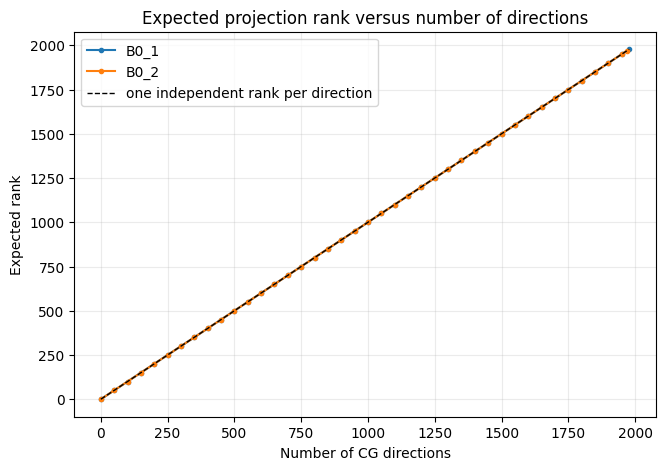

In [4]:
box_results = {}

for box_name, box in effective_boxes.items():
    ell_hat = scale * box[:, 0]
    u_hat = scale * box[:, 1]

    result = conjugate_gradient_projection_history(
        A=A_hat,
        b=b_hat,
        ell0=ell_hat,
        u0=u_hat,
        coordinate_indices=tracked_indices,
        period=contraction_period,
        rtol=cg_rtol,
        atol=cg_atol,
        max_iterations=cg_max_iterations,
    )
    if not result["converged"]:
        raise RuntimeError(f"{box_name} CG did not converge in {cg_max_iterations} iterations.")

    result["box_name"] = box_name
    result["ell_history_x"] = result["ell_history"] / scale[tracked_indices][None, :]
    result["u_history_x"] = result["u_history"] / scale[tracked_indices][None, :]
    initial_width = box[tracked_indices, 1] - box[tracked_indices, 0]
    width_history = result["u_history_x"] - result["ell_history_x"]
    with np.errstate(divide="ignore", invalid="ignore"):
        result["shrinkage_history"] = np.clip(
            100.0 * (1.0 - width_history / initial_width[None, :]),
            0.0,
            100.0,
        )

    final_ell = result["ell_history_x"][-1]
    final_u = result["u_history_x"][-1]
    result["tracked_contains_solution"] = bool(
        np.all((final_ell <= x_star[tracked_indices]) & (x_star[tracked_indices] <= final_u))
    )
    box_results[box_name] = result

    print(f"{box_name} CG iterations: {len(result['residual_norms'])}")
    print(f"{box_name} final residual norm: {result['residual_norms'][-1]:.6e}")
    print(f"{box_name} contraction calls: {len(result['iterations']) - 1}")
    print(
        f"{box_name} final mean tracked shrinkage: "
        f"{np.nanmean(result['shrinkage_history'][-1]):.2f}%"
    )
    print(
        f"{box_name} final tracked enclosure contains the converged solution: "
        f"{result['tracked_contains_solution']}"
    )

max_direction_count = max(result["iterations"][-1] for result in box_results.values())
fig, ax = plt.subplots(figsize=(7.5, 5))
for box_name, result in box_results.items():
    ax.plot(
        result["iterations"],
        result["expected_rank_history"],
        marker="o",
        markersize=3,
        label=box_name,
    )
ax.plot(
    [0, max_direction_count],
    [0, max_direction_count],
    color="black",
    linestyle="--",
    linewidth=1,
    label="one independent rank per direction",
)
ax.set_xlabel("Number of CG directions")
ax.set_ylabel("Expected rank")
ax.set_title("Expected projection rank versus number of directions")
ax.grid(alpha=0.25)
ax.legend()
plt.show()


## Residual comparison with standard CG

For each initial box, SciPy's standard CG and the CG-projection implementation below start from the same scaled box center and use the same convergence tolerances. The plotted residual is $\lVert b-Ax_k\rVert_2$, with the iteration number on the horizontal axis.


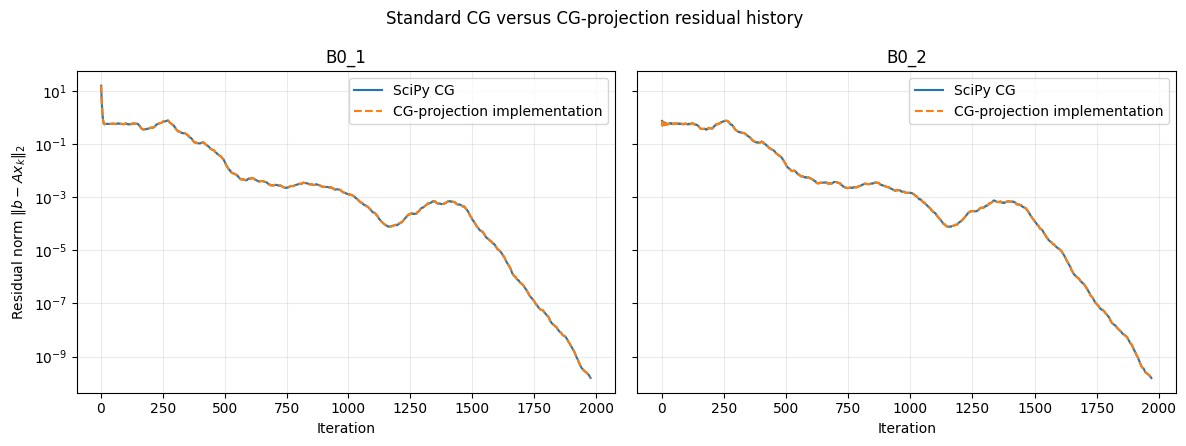

In [5]:
standard_cg_residuals = {}

for box_name, box in effective_boxes.items():
    ell_hat = scale * box[:, 0]
    u_hat = scale * box[:, 1]
    x0 = 0.5 * (ell_hat + u_hat)
    residual_history = []

    def record_residual(xk, history=residual_history):
        history.append(float(np.linalg.norm(b_hat - A_hat @ xk)))

    _, standard_cg_info = cg(
        A_hat,
        b_hat,
        x0=x0,
        rtol=cg_rtol,
        atol=cg_atol,
        maxiter=cg_max_iterations,
        callback=record_residual,
    )
    if standard_cg_info != 0:
        raise RuntimeError(
            f"Standard CG for {box_name} did not converge; info={standard_cg_info}."
        )
    standard_cg_residuals[box_name] = np.asarray(residual_history)

fig, axes = plt.subplots(1, len(box_results), figsize=(12, 4.5), sharey=True)
axes = np.atleast_1d(axes)
for ax, (box_name, result) in zip(axes, box_results.items()):
    standard_residuals = standard_cg_residuals[box_name]
    implementation_residuals = result["residual_norms"]
    ax.semilogy(
        np.arange(1, len(standard_residuals) + 1),
        standard_residuals,
        label="SciPy CG",
    )
    ax.semilogy(
        np.arange(1, len(implementation_residuals) + 1),
        implementation_residuals,
        linestyle="--",
        label="CG-projection implementation",
    )
    ax.set_xlabel("Iteration")
    ax.set_title(box_name)
    ax.grid(alpha=0.25, which="both")
    ax.legend()

axes[0].set_ylabel(r"Residual norm $\|b-Ax_k\|_2$")
fig.suptitle("Standard CG versus CG-projection residual history")
fig.tight_layout()
plt.show()


## Controllable animation

The single retained diagnostic animation shows coordinate-wise box contraction. Because the plate system is large, the horizontal axis contains 80 evenly sampled original coordinate indices. The frame slider advances through the 50-direction checkpoints and includes the final convergence checkpoint.


In [6]:
def display_coordinate_contraction_animation(results, indices, title):
    frame_iterations = np.unique(
        np.concatenate([result["iterations"] for result in results.values()])
    )

    finite_values = np.concatenate([
        result["shrinkage_history"][np.isfinite(result["shrinkage_history"])]
        for result in results.values()
    ])
    y_max = max(1.0, float(np.max(finite_values)) * 1.05) if finite_values.size else 1.0

    fig, ax = plt.subplots(figsize=(9, 4.5))
    lines = {}
    for box_name, result in results.items():
        line, = ax.plot(
            indices,
            np.nan_to_num(result["shrinkage_history"][0]),
            marker="o",
            markersize=3,
            linewidth=1,
            label=box_name,
        )
        lines[box_name] = line

    label = ax.text(0.02, 0.95, "", transform=ax.transAxes, va="top")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set(xlim=(indices[0], indices[-1]), ylim=(0, y_max))
    ax.set_xlabel("Original coordinate index (evenly sampled)")
    ax.set_ylabel("Width reduction (% of original width)")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend()

    def update(frame):
        direction_count = frame_iterations[frame]
        artists = []
        for box_name, result in results.items():
            history_index = np.searchsorted(
                result["iterations"], direction_count, side="right"
            ) - 1
            lines[box_name].set_ydata(
                np.nan_to_num(result["shrinkage_history"][history_index])
            )
            artists.append(lines[box_name])
        label.set_text(f"CG directions {direction_count}")
        return (*artists, label)

    animation = FuncAnimation(
        fig,
        update,
        frames=len(frame_iterations),
        interval=180,
        repeat_delay=1000,
    )
    display(HTML(animation.to_jshtml(fps=5, default_mode="loop")))
    plt.close(fig)
    return animation


### Coordinate contraction

In [7]:
coordinate_contraction_animation = display_coordinate_contraction_animation(
    box_results,
    tracked_indices,
    "Plate-system coordinate contraction",
)
